# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business. 

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# read the data
df = pd.read_csv('../data/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [3]:
# get the shape of the dataframe
df.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns in the data.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [4]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The data is made up of a mix of:
- int64 (order_id, customer_id, food_preperation_time, delivery_time)
- float64 (cost_of_the_order)
- object (restaurant_name, cuisine_type, day_of_the_week, rating)



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [5]:
# Determine if there are any missing values in the dataset
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
There is no missing data for rating.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [6]:
# Generate the summary statistics for numerical columns
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations:
The statistics for food preperation (minutes):
- minimum: 20.00
- average: 27.371970
- maximum: 35.00

### **Question 5:** How many orders are not rated? [1 mark]

In [7]:
# Check unique values in rating column
df['rating'].unique()

# Count occurrence of each rating value
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

#### Observations:
736 order are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [8]:
# Replacing the 'Not rated' with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)
# Ensure rating is numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [9]:
# Confirm the changes
df['rating'].value_counts()

rating
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64

In [10]:
# Review missing values again
df.isnull().sum()

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64

### Observations:
There are in fact 736 entries with no rating.

In [11]:
# Apply the mean imputation strategy to fill missing values in the 'rating' column, on a per 'restaurant_name' basis
# Doing this on a per-restaurant ensures one restaurant's ratings do not skew another's
df['rating'] = df.groupby('restaurant_name')['rating'].transform(lambda x: x.fillna(x.mean()))

In [12]:
# Inspecting the number of orders per restaurant
df['restaurant_name'].value_counts()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1
Name: count, Length: 178, dtype: int64

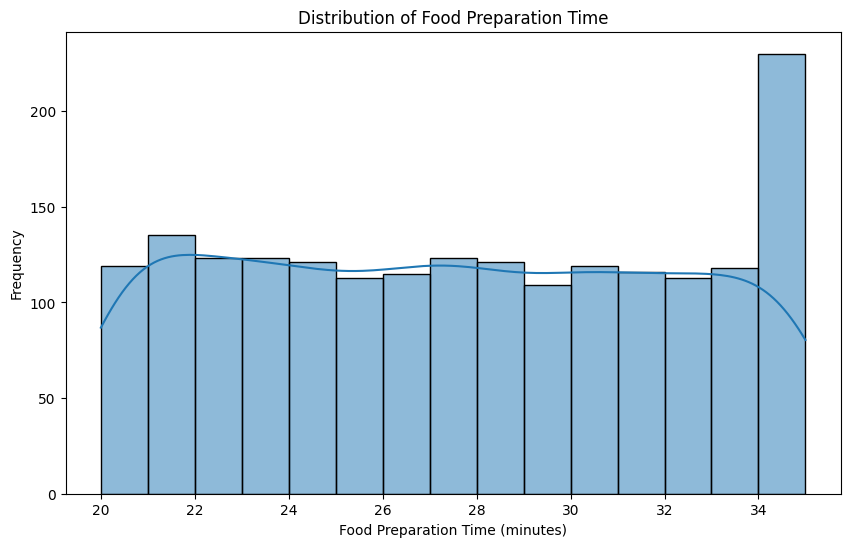

In [13]:
# Histogram of food preparation time
plt.figure(figsize=(10, 6))
sns.histplot(df['food_preparation_time'], bins=15, kde=True)
plt.title('Distribution of Food Preparation Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.ylabel('Frequency')
plt.show()

There is a marked deviation from the average prep time. It might be worth exploring if this is for a specific sub-set of restaurants, or a cuisine type which inherently takes longer to prepare.

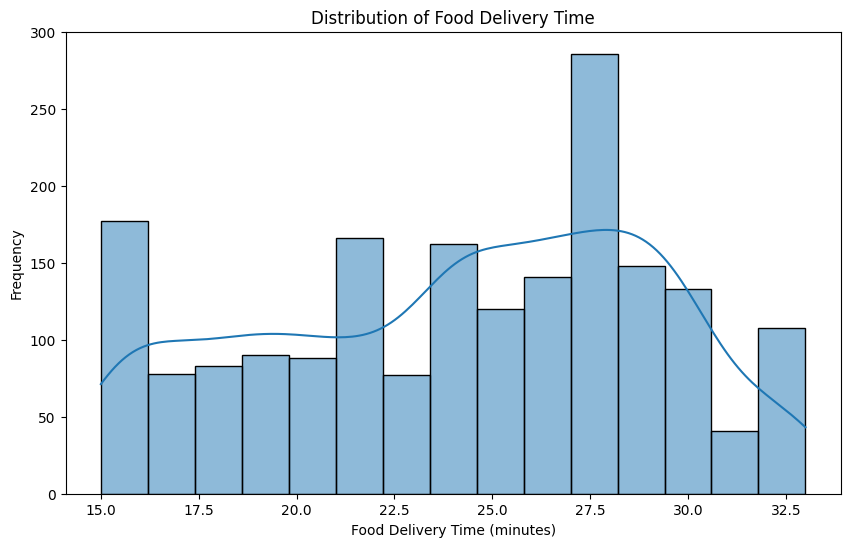

In [14]:
# Histogram of food delivery time
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time'], bins=15, kde=True)
plt.title('Distribution of Food Delivery Time')
plt.xlabel('Food Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

Delivery time is a bit lumpy, but this is to be expected, due to the spread of locations and delivery locations.

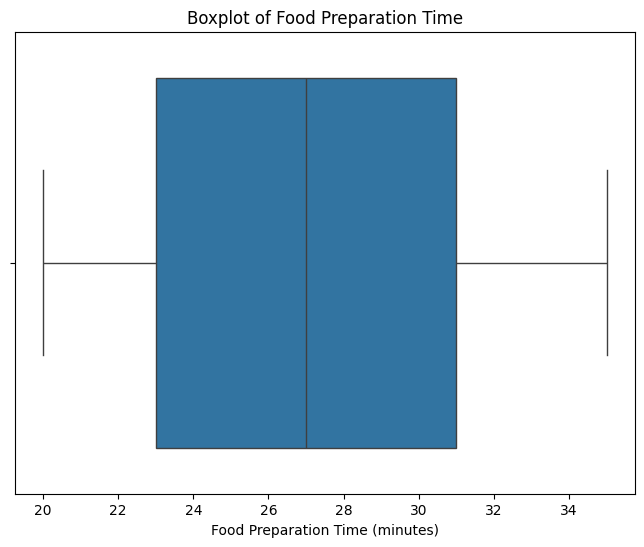

In [15]:
# Boxplot of food preparation time
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['food_preparation_time'])
plt.title('Boxplot of Food Preparation Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.show()

There doesn't appear to be any outlyers in the food prep time.

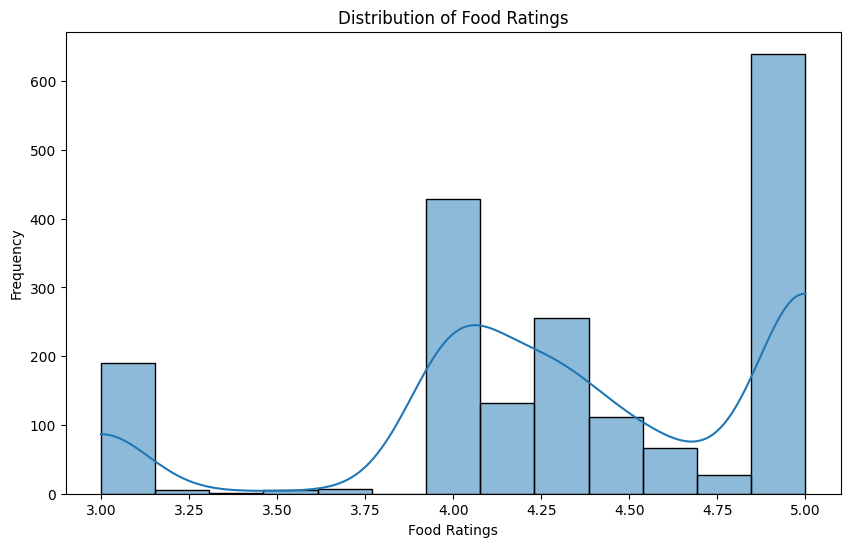

In [16]:
# Histogram of food ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], kde=True)
plt.title('Distribution of Food Ratings')
plt.xlabel('Food Ratings')
plt.ylabel('Frequency')
plt.show()

The majority of the ratings are very positive. It may be worth understanding how much prep and delivery time influence the final rating. Additionally exploring the ratings across the restaurants might provide some insights too.

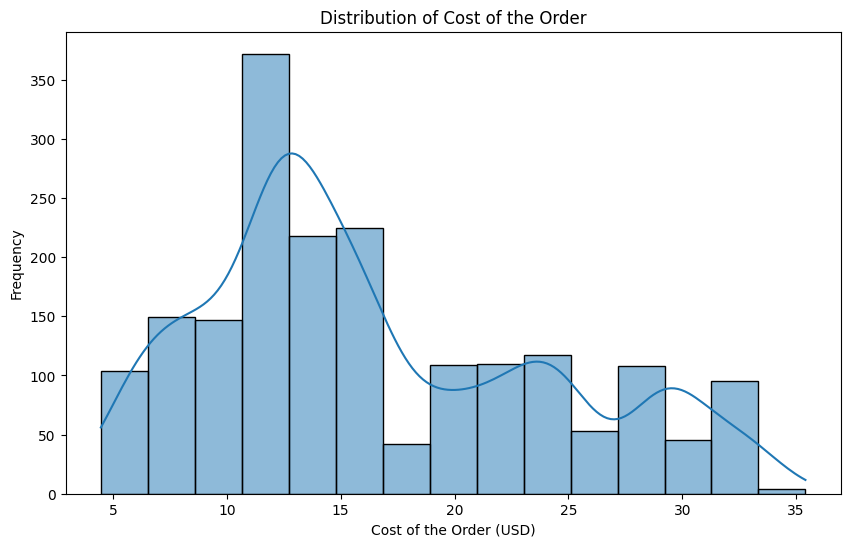

In [17]:
# Histogram of cost of the order
plt.figure(figsize=(10, 6))
sns.histplot(df['cost_of_the_order'], bins=15, kde=True)
plt.title('Distribution of Cost of the Order')
plt.xlabel('Cost of the Order (USD)')
plt.ylabel('Frequency')
plt.show()

Cost is right-skewed. Might be worth exploring cost/rating correlation.

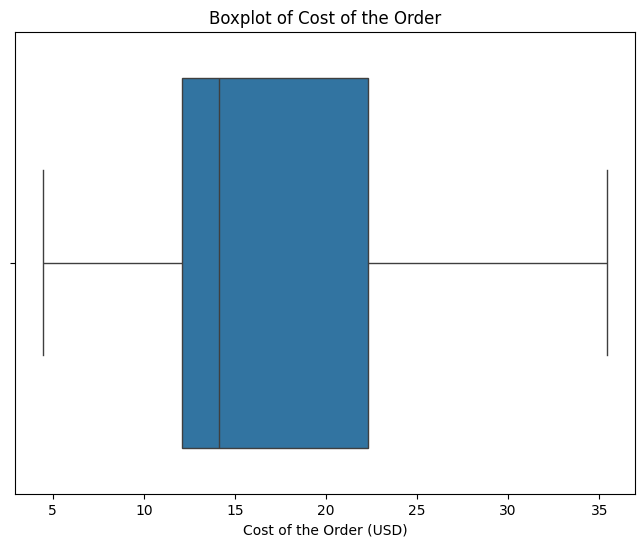

In [18]:
# Boxplot of cost of the order
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['cost_of_the_order'])
plt.title('Boxplot of Cost of the Order')
plt.xlabel('Cost of the Order (USD)')
plt.show()

No outliers detected in cost of the order

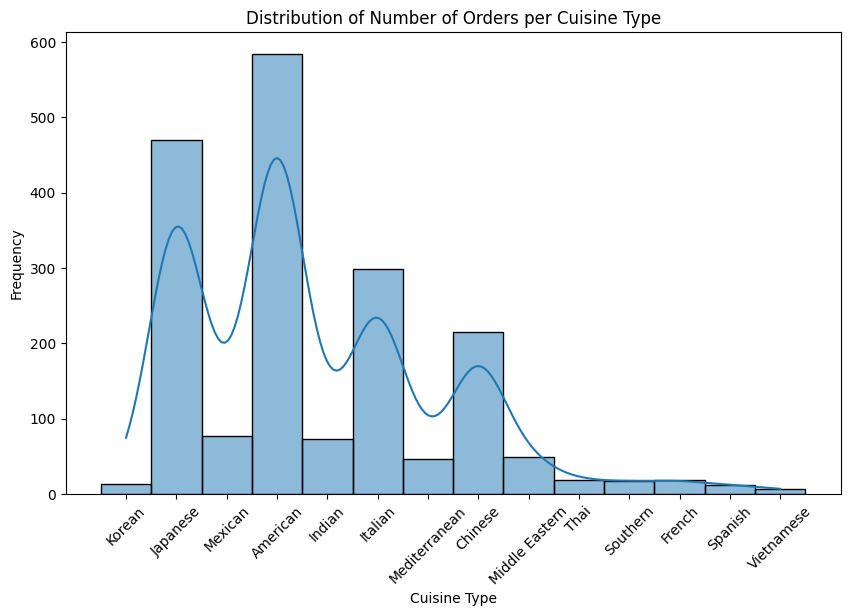

In [19]:
# Histogram of number of orders per cuisine type
plt.figure(figsize=(10, 6))
sns.histplot(df['cuisine_type'], kde=True)
plt.title('Distribution of Number of Orders per Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

### Observations:
It is clear that Japanese, American, Italian and Chinese are the favourite cuisine types being ordered.

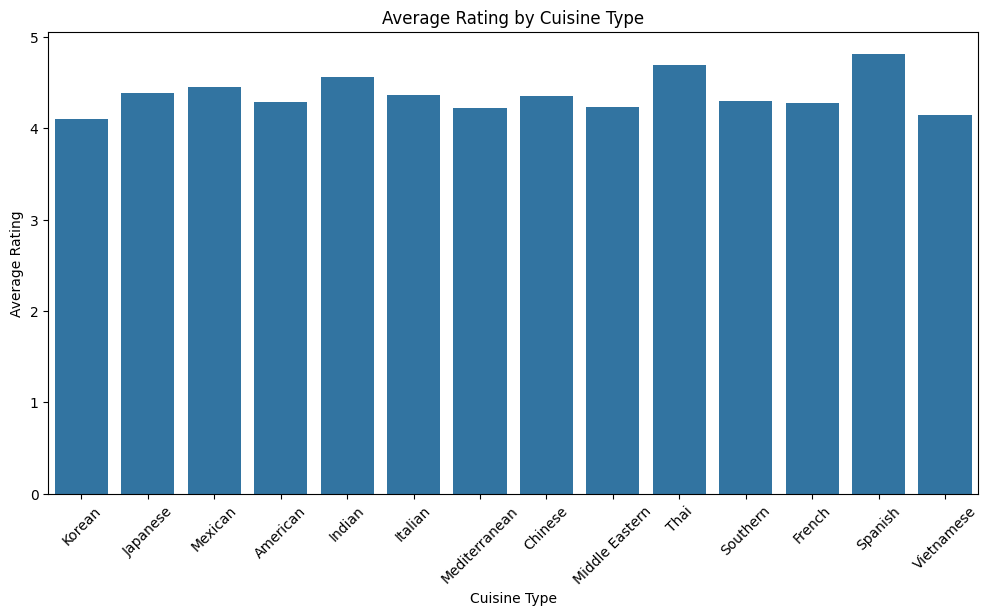

In [20]:
# Explore the relationship between cuisine type and average rating
plt.figure(figsize=(12, 6))
sns.barplot(x='cuisine_type', y='rating', data=df, errorbar=None)
plt.title('Average Rating by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

### Observations
Whilst we determined previously that there are 4 cuisine types that are far more popular than the rest, there is not such a clear difference in average rating. Suggesting preference rather than quality causing the former disparity.

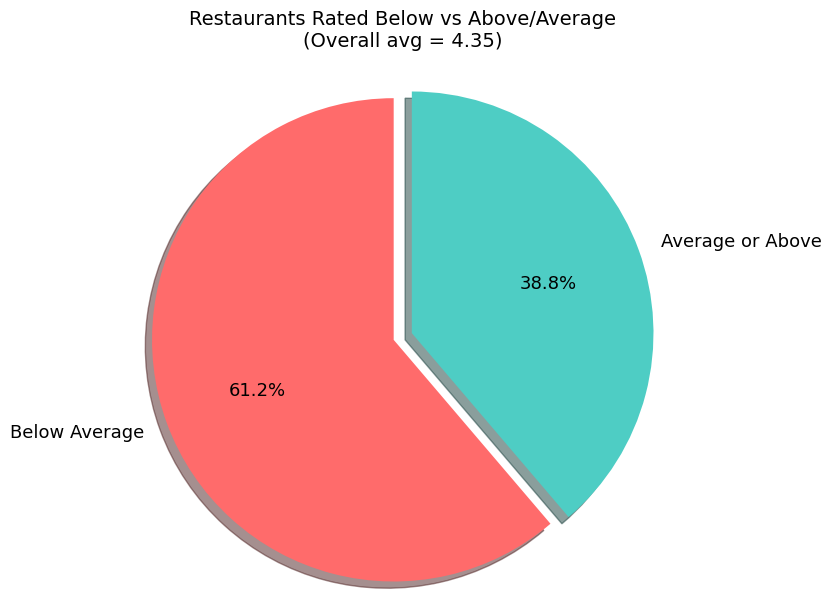

In [21]:
# Identify the average rating and the restaurants with below average ratings

average_rating = df['rating'].mean()
number_of_restaurants = df['restaurant_name'].nunique()
below_average_restaurants = df[df['rating'] < average_rating]['restaurant_name'].unique()
number_below_average = len(below_average_restaurants)
# Calculate average rating per below-average restaurant
for restaurant in below_average_restaurants:
    per_restaurant_average_rating = df[df['restaurant_name'] == restaurant]['rating'].mean()

# Pie chart
labels = ['Below Average', 'Average or Above']
sizes = [number_below_average, number_of_restaurants - number_below_average]
colors = ['#ff6b6b', '#4ecdc4']
explode = (0.08, 0)  # slightly separate the below-average slice

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 13})
plt.title(f'Restaurants Rated Below vs Above/Average\n(Overall avg = {average_rating:.2f})', fontsize=14, pad=15)
plt.axis('equal')
plt.show()


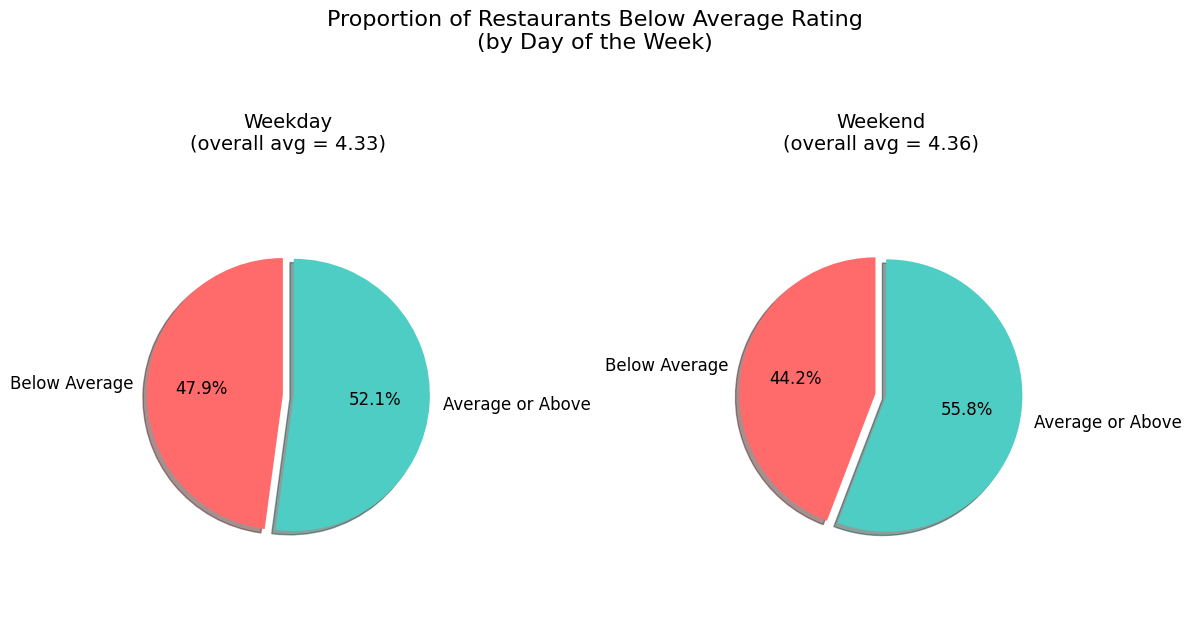

In [22]:
# Analyze ratings by day of the week

# Remove rows with missing ratings for this analysis
df_valid = df.dropna(subset=['rating'])

# ────────────────────────────────────────────────
# Calculate stats per day type
grouped = df_valid.groupby('day_of_the_week')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Proportion of Restaurants Below Average Rating\n(by Day of the Week)", fontsize=16, y=1.05)

for i, (day_type, group) in enumerate(grouped):
    if group.empty:
        axes[i].text(0.5, 0.5, f"No data for {day_type}", ha='center', va='center')
        axes[i].axis('off')
        continue
    
    # Overall average rating in this group
    avg_rating = group['rating'].mean()
    
    # Average rating per restaurant (only in this group)
    restaurant_avg = group.groupby('restaurant_name')['rating'].mean().reset_index(name='avg_rating')
    
    # Flag restaurants below the group's average
    below = restaurant_avg['avg_rating'] < avg_rating
    num_below = below.sum()
    total_rest = len(restaurant_avg)
    
    sizes = [num_below, total_rest - num_below]
    labels = ['Below Average', 'Average or Above']
    colors = ['#ff6b6b', '#4ecdc4']
    explode = (0.08, 0)
    
    axes[i].pie(sizes, explode=explode, labels=labels, colors=colors,
                autopct='%1.1f%%', shadow=True, startangle=90,
                textprops={'fontsize': 12})
    axes[i].set_title(f"{day_type}\n(overall avg = {avg_rating:.2f})", fontsize=14, pad=10)
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

### Observations
Weekend ratings are better than Weekday ratings. The longer delivery times appear to be hurting ratings.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [23]:
# Identify the top 5 restaurants by number of orders
top_restaurants = df['restaurant_name'].value_counts().head(5)

#### Observations:
Top 5 restaurants based on number of orders received. Shake Shack is the clear favourite.

- Shake Shack: 219
- The Meatball Shop: 132
- Blue Ribbon Sushi: 119
- Blue Ribbon Fried Chicken: 96
- Parm: 68


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [24]:
# Determine most popular cuisine type on the weekends
weekend_orders = df[df['day_of_the_week'].isin(['Weekend'])]
popular_cuisine_weekend = weekend_orders['cuisine_type'].value_counts().idxmax()

#### Observations:
American cuisine is the most popular type at the weekends.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [25]:
# Identify the percentage of orders costing more than $20
total_number_of_orders = len(df)
orders_above_20 = len(df[df['cost_of_the_order'] > 20])
percentage_above_20 = (orders_above_20 / total_number_of_orders) * 100

#### Observations:
29.24% of orders cost more than $20

### **Question 10**: What is the mean order delivery time? [1 mark]

In [26]:
# Calculate the mean delivery time
mean_delivery_time = df['delivery_time'].mean()

#### Observations:
The mean delivery time is 24.16 minutes

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [27]:
# Identify the top 3 customers, based on number of orders placed
top_customers = df['customer_id'].value_counts().head(3)


#### Observations:

The top 3 customers, and the number of orders they placed are:

- id: 52832 - 13 Orders
- id: 47440 - 10 Orders
- id: 83287 - 9 Orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


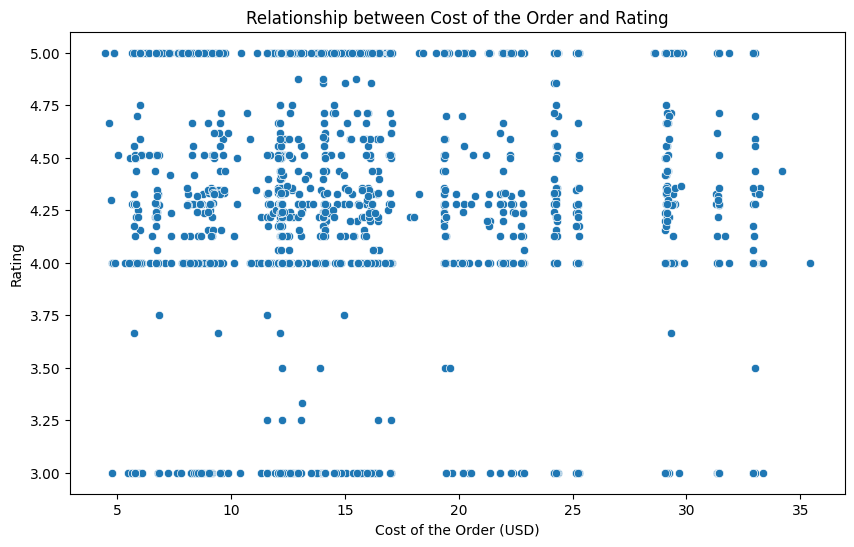

In [28]:
# Explore relationship between cost of the order and rating
plt.figure(figsize=(10, 6))
sns.scatterplot(x='cost_of_the_order', y='rating', data=df)
plt.title('Relationship between Cost of the Order and Rating')
plt.xlabel('Cost of the Order (USD)')
plt.ylabel('Rating')
plt.show()

### Observations:
There doesn't appear to be a corrolation between cost and rating.

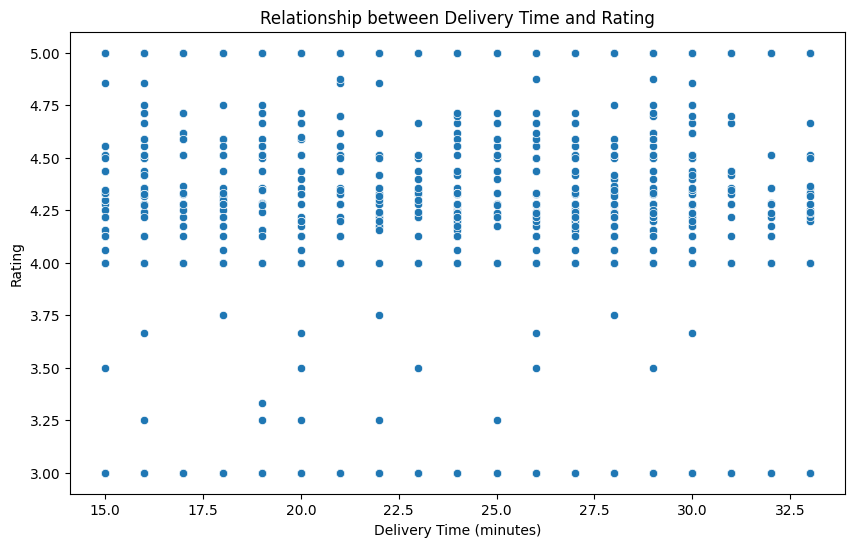

In [29]:
# Explore relationship between rating and delivery time
plt.figure(figsize=(10, 6))
sns.scatterplot(x='delivery_time', y='rating', data=df)
plt.title('Relationship between Delivery Time and Rating')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Rating')
plt.show()

### Observations:
No real corrolation between delivery time and ratings

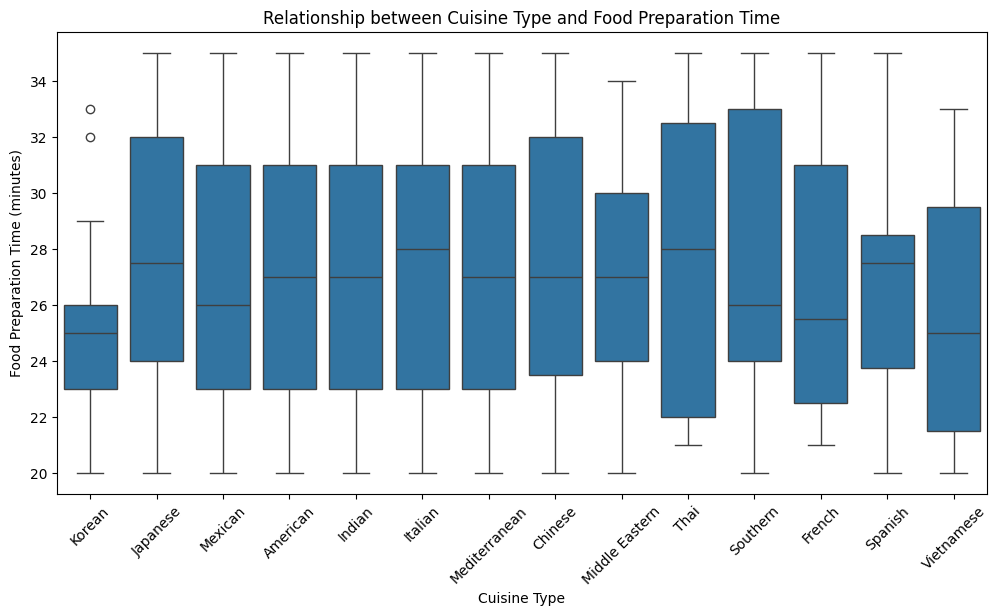

In [30]:
# Explore the relationship between cuisine type and preparation time
plt.figure(figsize=(12, 6))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df)
plt.title('Relationship between Cuisine Type and Food Preparation Time')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=45)
plt.show()

### Observations:
For the most part Korean food is prepared faster than any other, save for a couple of outliers. There is not much to be gathered from the relationship between cuisine type and prep time.

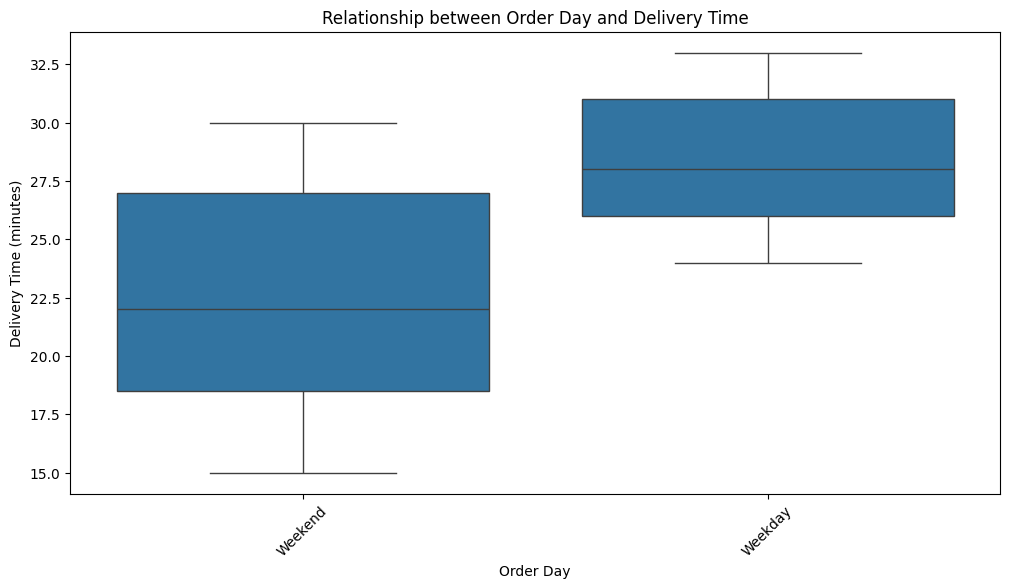

In [31]:
# Explore the relationship between delivery time and order day
plt.figure(figsize=(12, 6))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df)
plt.title('Relationship between Order Day and Delivery Time')
plt.xlabel('Order Day')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45)
plt.show()

### Observations:
It is clear that weekday delivery times are much longer than weekend delivery time.
It might help to understand if this is due to diferences in availability of delivery drivers or restaurant staff or the fact that there is heavier traffic.
Worth looking at the relationship between number of orders and day of the week too. Would be especially interesting if there are more orders on the weekend, but they are delivered faster.

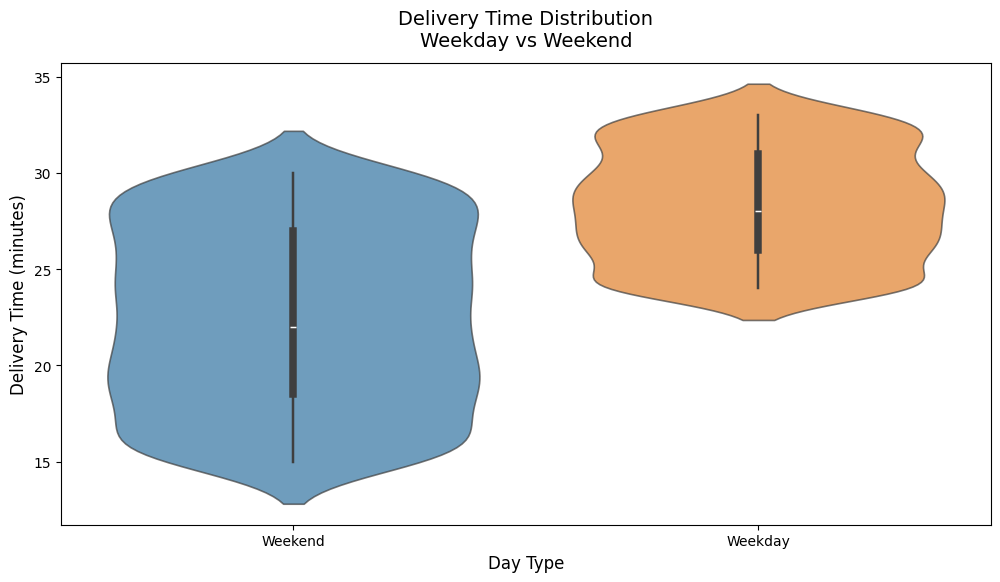

In [32]:
# Explore the relationship between delivery times, day of the week and number of orders placed
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x='day_of_the_week',
    y='delivery_time',
    hue='day_of_the_week',
    linewidth=1.2,
    alpha=0.7
)
plt.title('Delivery Time Distribution\nWeekday vs Weekend', fontsize=14, pad=12)
plt.xlabel('Day Type', fontsize=12)
plt.ylabel('Delivery Time (minutes)', fontsize=12)
plt.show()

### Observations:
It does seem that there is some reason, not available in the data, which is causing Weekday delivery times to be notably longer than Weekend delivery times.

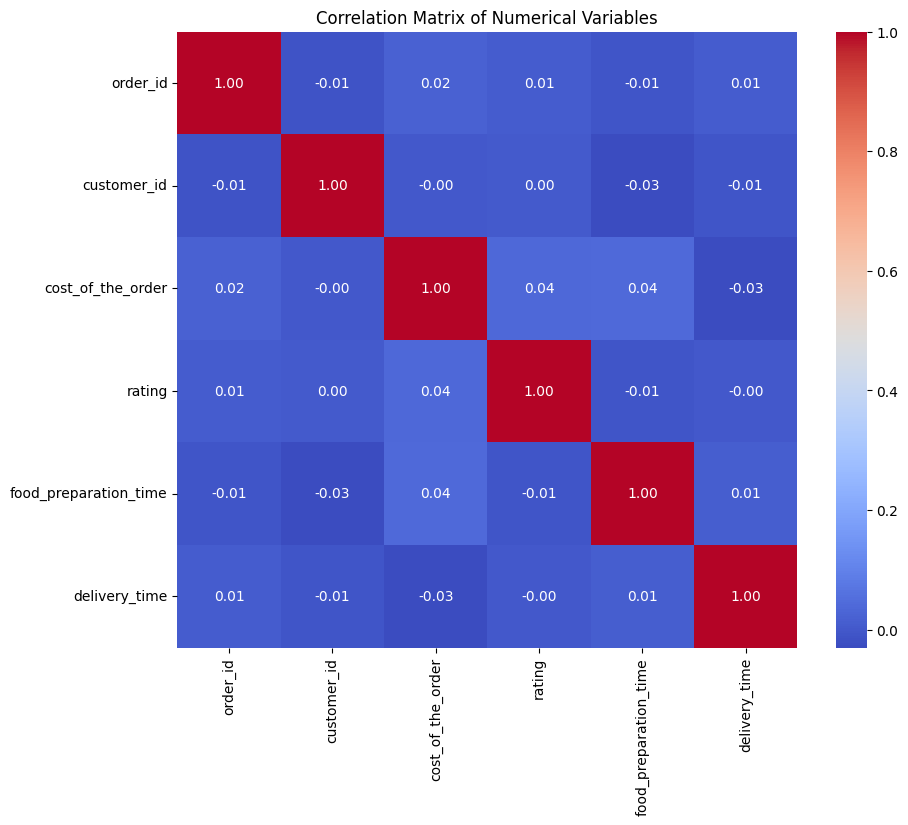

In [33]:
# Heatmap to visualize correlation between numerical variables
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observations:
There appears to be no strong correlations between any of the data we have.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [34]:
# Identify restaurants eligible for the promo offer. More than 50 ratings and average rating above 4

# Restaurants with more than 50 orders:
order_counts = df['restaurant_name'].value_counts()
restaurants_above_50_orders = order_counts[order_counts > 50]

# Restaurants with average rating above 4:
average_ratings = df.groupby('restaurant_name')['rating'].mean()
restaurants_above_4_rating = average_ratings[average_ratings > 4]

# Eligible restaurants are those that meet both criteria
eligible_restaurants = set(restaurants_above_50_orders.index).intersection(set(restaurants_above_4_rating.index))

#### Observations:
The restaurants meeting the criteriaare:
- Blue Ribbon Fried Chicken
- The Meatball Shop
- Shake Shack
- RedFarm Hudson
- Blue Ribbin Sushi
- Parm
- RedFarm Broadway

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [35]:
# Total value of orders over $20
total_value_above_20 = df[df['cost_of_the_order'] > 20]['cost_of_the_order'].sum()

# Total value of orders between $6 and $20
total_value_between_6_and_20 = df[(df['cost_of_the_order'] >= 6) & (df['cost_of_the_order'] <= 20)]['cost_of_the_order'].sum()

# Company earnings:
above_20_earnings = total_value_above_20 * 0.25

between_6_and_20_earnings = total_value_between_6_and_20 * 0.15

total_earnings = above_20_earnings + between_6_and_20_earnings


#### Observations:
The companies net earnings are as follows:
- From orders over 20 dollars, at 25percent: $3,688.73
- From orders between 6 and 20 dollars at 15percent: $2,417.01
- Total earnings: $6,105.73


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [36]:
# Calculate the percentage of orders where the preperation and delivery times combined is more than 60 minutes
total_orders = len(df)
df['combined_time'] = df['food_preparation_time'] + df['delivery_time']
orders_above_60 = len(df[df['combined_time'] > 60])
percentage_above_60 = (orders_above_60 / total_orders) * 100

#### Observations:
10.54% of the orders have a combined order time (preperation _ delivery) of more than 60 minutes.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [37]:
# Anylise the difference in delivery times between weekdays and weekends
weekday_delivery_times = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
weekend_delivery_times = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

# Percentage difference
percentage_difference = ((weekday_delivery_times - weekend_delivery_times) / weekend_delivery_times) * 100

#### Observations:
On average, Weekday delivery times are longer than Weekend deliveries - about 26.12% longer
- Average Weekday delivery time: 28.34 minutes
- Average Weekend delivery time: 22.47 minutes


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Weekday deliveries are noticably slower than Weekend deliveries. There is nothing in the data which indicates why that might be.
*  Japanese, American, Italian and Chinese food is clearly favoured by the demographic being served.
*  A majority of restaurants - 61.2%, have an average rating below the overall average of 4.35. When splitting this analysis between Weekend and Weekday, it is clear that Weekday deliveries get lower ratings on average.

### Recommendations:

*  Seeing as the ratings are atributed to the restaurants on a per order basis, it is also likely that the delivery service itself is being included in that judgement, and not just the food. This is highlighted as a potential issue when the data is split between Weekend and Weekday ratings. With this in mind the business should focus on understanding why Weekday deliveries are so much slower than Weekend deliveries.
*  Depending on what the focus of the business is, there are two options for approaching the fact that 4 cuisine types are so much more popular that the other types:
    - Create additional marketing or offers for those restaurants outside of the main 4 cusine types. This could improve awareness of these restaurants and improve their order rates.
    - Double down on the 4 key cuisine types, creating specific offers for these types. This could harm the restaurants outside of this group of 4 though.
*  Work with the 'below average' restaurants to understand how the average ratings can be improved.
*  Carry out further analysis to determine:
    - Are the restaurants 'below average' in the two groups (Weekend and Weekday) the same restaurants?
    - How does the average preperation time compare to the average delivery time for these two groups? Is this impacting ratings?

---